## Cleanup: Free Apple Silicon (MPS) Memory

This utility function ensures that any previously loaded models and tokenizers are deleted and GPU memory is cleared.

This is particularly useful when re-running sections or switching models on Apple Silicon (M1/M2) machines using `torch.mps`.

We call this cleanup before loading new models to avoid memory errors or slowdowns.

In [1]:
def cleanup_mps_memory():
    """
    Frees MPS memory by deleting global variables 'model' and 'tokenizer' if they exist.
    Useful when you want to avoid passing model/tokenizer manually.
    """
    import gc
    import torch

    for var in ['model', 'tokenizer']:
        if var in globals():
            print(f"🔹 Deleting: {var}")
            del globals()[var]

    gc.collect()
    torch.mps.empty_cache()
    print("MPS memory cleaned.")
cleanup_mps_memory()

MPS memory cleaned.


## Load Dataset

We load the `ag_news` dataset, a news classification corpus with short news headlines and articles from 4 categories.

To keep experiments fast, we work with only the **first 2,000 examples**. This subset is large enough for topic discovery but small enough to train and visualize quickly.

In [3]:
from datasets import load_dataset
dataset = load_dataset("maartengr/arxiv_nlp")['train']
abstracts = dataset["Abstracts"]
titles = dataset["Titles"]

In [4]:
abstracts[:3]

['  In this paper Arabic was investigated from the speech recognition problem\npoint of view. We propose a novel approach to build an Arabic Automated Speech\nRecognition System (ASR). This system is based on the open source CMU Sphinx-4,\nfrom the Carnegie Mellon University. CMU Sphinx is a large-vocabulary;\nspeaker-independent, continuous speech recognition system based on discrete\nHidden Markov Models (HMMs). We build a model using utilities from the\nOpenSource CMU Sphinx. We will demonstrate the possible adaptability of this\nsystem to Arabic voice recognition.\n',
 '  In this paper we present the creation of an Arabic version of Automated\nSpeech Recognition System (ASR). This system is based on the open source\nSphinx-4, from the Carnegie Mellon University. Which is a speech recognition\nsystem based on discrete hidden Markov models (HMMs). We investigate the\nchanges that must be made to the model to adapt Arabic voice recognition.\n  Keywords: Speech recognition, Acoustic mo

In [81]:
len(abstracts)

44949

In [2]:
from datasets import load_dataset
data = load_dataset("ag_news")['train']
data = data.select(range(2000))
texts = data['text']

/opt/miniconda3/envs/re/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
texts[:3]

["Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
 'Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\\which has a reputation for making well-timed and occasionally\\controversial plays in the defense industry, has quietly placed\\its bets on another part of the market.',
 "Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\\about the economy and the outlook for earnings are expected to\\hang over the stock market next week during the depth of the\\summer doldrums."]

## Embeddings block - Create Text Embeddings

We use a lightweight and efficient sentence transformer: `all-MiniLM-L6-v2` to convert each text into a dense numerical vector.

Each resulting embedding has 384 dimensions and captures the semantic meaning of the input text.

These embeddings will be used for clustering and topic modeling.


In [4]:
from sentence_transformers import SentenceTransformer

In [8]:
emb_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = emb_model.encode(texts, show_progress_bar=True)

/opt/miniconda3/envs/re/lib/python3.10/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Batches: 100%|██████████████████████████████████| 63/63 [00:02<00:00, 24.67it/s]


In [9]:
embeddings.shape

(2000, 384)

## Dimensiality reduction block - Reduce Dimensions with UMAP

We reduce the high-dimensional embeddings to just 7 dimensions using **UMAP**, a powerful nonlinear dimensionality reduction algorithm.

This step makes clustering easier and faster, and helps when visualizing the document space later.

We use cosine distance to preserve semantic similarity.


In [10]:
from umap import UMAP

umap_model = UMAP(
    n_components=7, min_dist=0.0, metric='cosine', random_state=42
)

reduced_embeddings = umap_model.fit_transform(embeddings)

/opt/miniconda3/envs/re/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## Clustering block - Discover Clusters with HDBSCAN

Using **HDBSCAN**, we cluster the reduced embeddings into meaningful groups (topics). HDBSCAN is a density-based clustering algorithm that can detect noise and doesn't require specifying the number of clusters.

We set `min_cluster_size=30` to control the granularity of topic detection.

The resulting labels will inform the topic modeling step.

In [11]:
from hdbscan import HDBSCAN

hdbscan_model = HDBSCAN(
    min_cluster_size=30, metric='euclidean', cluster_selection_method='eom'
).fit(reduced_embeddings)
clusters = hdbscan_model.labels_

In [12]:
len(set(clusters))

13

In [22]:
import numpy as np

cluster = 1
for index in np.where(clusters==1)[0][:3]:
    print('\n' + texts[index])


Barrel of Monkeys, 2004 Edition: Notes on Philippine Elections Well, it's election time in the Republic of the Philippines, and that means the monkeys are rolling around in those political barrels, having as much fun as they can while laughing their heads off at the strange goings-on that characterize a democratic process loosely based on the American model  but that de facto looks more like a Fellini movie crossed with a Tom and Jerry cartoon - column includes a useful election-year glossary!

Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezuelans turned out early\and in large numbers on Sunday to vote in a historic referendum\that will either remove left-wing President Hugo Chavez from\office or give him a new mandate to govern for the next two\years.

Who are Ch #225;vez's opponents? On Sunday, Venezuelans will decide whether to cut short the president's term, which is due to end in 2006.


## Topic modeling block - Build and Fit BERTopic

We now apply **BERTopic**, a state-of-the-art topic modeling library, combining:

- Sentence embeddings
- Dimensionality reduction (UMAP)
- Clustering (HDBSCAN)
- Topic representation (via class-based TF-IDF)

The `.fit()` method trains the pipeline and discovers initial topic representations using keywords.


In [23]:
from bertopic import BERTopic

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [24]:
topic_model = BERTopic(
    embedding_model=emb_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
).fit(texts, embeddings)

2025-05-18 20:31:48,249 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-18 20:31:51,001 - BERTopic - Dimensionality - Completed ✓
2025-05-18 20:31:51,001 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-18 20:31:51,018 - BERTopic - Cluster - Completed ✓
2025-05-18 20:31:51,019 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-18 20:31:51,046 - BERTopic - Representation - Completed ✓


#### View Extracted Topics

We inspect the top topics discovered by BERTopic. Each topic has:
- A topic number
- A count (number of documents assigned to it)
- A name (based on top keywords)
- Example representative documents

This gives us a good first view of what each cluster is about.

In [25]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,455,-1_the_to_of_in,"[the, to, of, in, and, for, on, new, with, reu...",[Army Won't Pay 15 Pct of Halliburton Bill WA...
1,0,396,0_the_athens_in_olympic,"[the, athens, in, olympic, of, to, ap, and, te...",[Phelps Pushes Gold-Medal Haul to Three ATHENS...
2,1,293,1_in_the_of_to,"[in, the, of, to, and, afp, iraq, najaf, on, ap]","[Iraq peace mission arrives in Najaf NAJAF, Ir..."
3,2,179,2_space_the_ap_of,"[space, the, ap, of, to, and, in, nasa, com, are]",[NASA Approves Robotic Hubble Repair Mission (...
4,3,139,3_oil_prices_stocks_on,"[oil, prices, stocks, on, in, reuters, july, t...","[Stocks Up on Earnings, Oil, Economic Data NE..."
5,4,110,4_microsoft_windows_security_to,"[microsoft, windows, security, to, xp, sp2, up...",[Windows XP Security Update Delayed Microsoft ...
6,5,106,5_profit_sales_reuters_fullquote,"[profit, sales, reuters, fullquote, lt, gt, qu...","[Home Depot Raises Outlook, Tops Estimates AT..."
7,6,92,6_hp_linux_to_the,"[hp, linux, to, the, software, its, for, of, a...",[Q amp;A: HP #39;s Livermore sees no need for ...
8,7,59,7_google_ipo_offering_auction,"[google, ipo, offering, auction, to, public, s...",[Google IPO Awaits Final Approval In a sign th...
9,8,58,8_apple_music_realnetworks_ipod,"[apple, music, realnetworks, ipod, for, dvd, s...","[RealNetworks Halves Music Prices, Sees Wider ..."


#### Manually Inspect Topic Keywords

We can explore what each topic contains by using `.get_topic(n)` for any topic ID `n`.

This returns a ranked list of keywords and their importance scores, which help us interpret the semantic meaning of each topic.

In [26]:
topic_model.get_topic(0)

[('the', 0.06297116410690402),
 ('athens', 0.036858412362381285),
 ('in', 0.03483070137093781),
 ('olympic', 0.031056281191261963),
 ('of', 0.030057702144047488),
 ('to', 0.02886330704368652),
 ('ap', 0.02768554312429051),
 ('and', 0.026641259838280664),
 ('team', 0.024541853597300652),
 ('for', 0.02440935290374937)]

In [27]:
topic_model.find_topics('topic modeling')

([9, 1, 2, 3, 10],
 [0.16111651, 0.09546271, 0.09210998, 0.07881025, 0.061244857])

In [30]:
topic_model.get_topic(11)

[('drugs', 0.0588685130253388),
 ('drug', 0.049566709831726466),
 ('to', 0.043211819270112285),
 ('by', 0.040186752292916406),
 ('scientists', 0.039014967033499784),
 ('prescription', 0.036073127939443485),
 ('the', 0.03560349576193328),
 ('human', 0.03326204873245183),
 ('that', 0.03183201667115663),
 ('vaccine', 0.030065295839462346)]

#### Visualize Topics with a Barchart

The `.visualize_barchart()` method lets us see a simple plot of each topic’s most important words.

It’s an easy way to get a quick overview of the topic landscape.

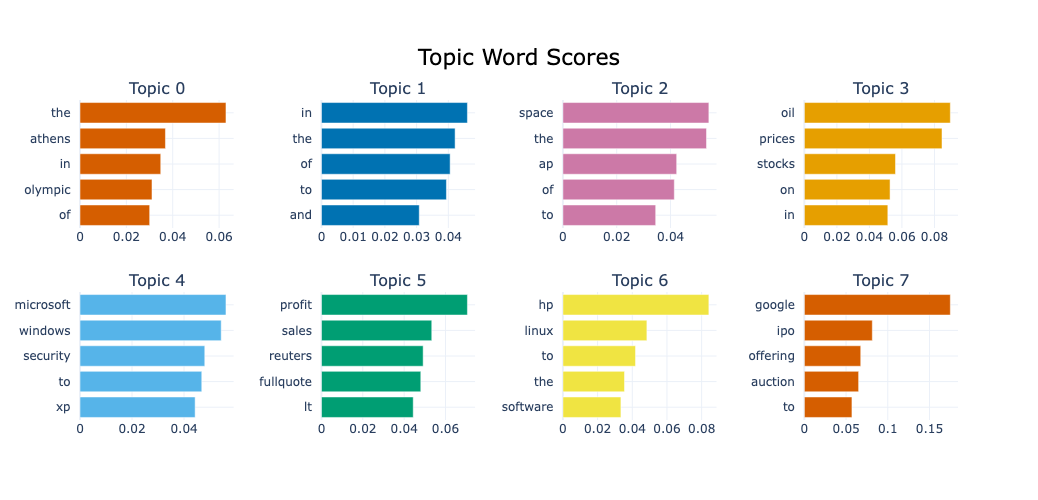

In [31]:
topic_model.visualize_barchart()

#### Compare Topic Representations

We define a helper function to compare the top N keywords in the original topic representations vs. updated ones after we apply new techniques (KeyBERT, MMR, or text generation).

This makes it easy to track how our topic labels evolve.

In [32]:
from copy import deepcopy
original_topics = deepcopy(topic_model.topic_representations_)

In [40]:
import pandas as pd

def compare_topic_representations(model, original_repr, top_n=5):
    rows = []
    for topic_idx in range(top_n):
        old_keywords = [kw for kw, _ in original_repr[topic_idx][:top_n]]
        new_keywords = [kw for kw, _ in model.get_topic(topic_idx)[:top_n]]

        row = {
            "Topic": topic_idx,
            "Original": " | ".join(old_keywords),
            "Updated": " | ".join(new_keywords)
        }
        rows.append(row)

    return pd.DataFrame(rows)

## KeyBERTInspired block - Enhance Topic Names with KeyBERT-Inspired Model

The `KeyBERTInspired` module replaces generic TF-IDF topic labels with better semantic keywords, using a method similar to the KeyBERT approach.

It selects more meaningful and diverse keywords from representative documents for each topic.


In [46]:
from bertopic.representation import KeyBERTInspired

keybert_repr = KeyBERTInspired()
topic_model.update_topics(texts, representation_model=keybert_repr)
compare_topic_representations(topic_model, original_topics)

,Topic,Original,Updated
0,0,the | athens | in | olympic | of,olympic | olympics | phelps | thorpe | medals
1,1,in | the | of | to | and,baghdad | najaf | iraqi | iraq | militants
2,2,space | the | ap | of | to,nasa | spacecraft | astronauts | rocket | manned
3,3,oil | prices | stocks | on | in,stocks | oil | market | investors | reuters
4,4,microsoft | windows | security | to | xp,xp | microsoft | updates | symantec | delayed


## MMR block - Diversify Topic Labels with MMR

We apply **Maximal Marginal Relevance**, which balances **relevance and diversity** in keyword selection.

By setting a `diversity` parameter (here, 0.3), we make sure the keywords aren’t just similar, but cover different aspects of the topic.

In [45]:
from bertopic.representation import MaximalMarginalRelevance

mmr_representation = MaximalMarginalRelevance(diversity=0.3)
topic_model.update_topics(texts, representation_model=mmr_representation)
compare_topic_representations(topic_model, original_topics)

,Topic,Original,Updated
0,0,the | athens | in | olympic | of,athens | olympic | ap | his | phelps
1,1,in | the | of | to | and,afp | najaf | ap | troops | reuters
2,2,space | the | ap | of | to,space | ap | nasa | scientists | earth
3,3,oil | prices | stocks | on | in,oil | prices | stocks | reuters | july
4,4,microsoft | windows | security | to | xp,microsoft | security | xp | sp2 | update


## Text generation block - Use Text-to-Text Generation for Better Topic Titles

Using the Flan-T5 model from Hugging Face, we generate human-like topic titles based on top keywords and sample documents.

This method can produce expressive and readable topic labels, especially useful for reports or presentations.


In [48]:
from transformers import pipeline
from bertopic.representation import TextGeneration

prompt = """
Write a specific title for a topic based on the following: [KEYWORDS]. Supporting docs: [DOCUMENTS]. 
Please very specific in describing topics.
"""

pipe = pipeline('text2text-generation', model='google/flan-t5-small')
textgen_repr = TextGeneration(
    pipe, prompt=prompt, doc_length=50, tokenizer="whitespace"
)
topic_model.update_topics(texts, representation_model=textgen_repr)
compare_topic_representations(topic_model, original_topics)

Token indices sequence length is longer than the specified maximum sequence length for this model (548 > 512). Running this sequence through the model will result in indexing errors
100%|███████████████████████████████████████████| 13/13 [00:01<00:00,  9.05it/s]


,Topic,Original,Updated
0,0,the | athens | in | olympic | of,Olympic Games: Thorpe Beats Phelps as U.S. Fig...
1,1,in | the | of | to | and,Iraqi leaders clash in Najaf | | | |
2,2,space | the | ap | of | to,NASA's chief urges manned space mission to orb...
3,3,oil | prices | stocks | on | in,U.S. stocks gain as oil prices fall | | | |
4,4,microsoft | windows | security | to | xp,Microsoft delays security update for Windows X...
